In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import os

# Projeto 3 de Algebra Linear Numérica

### 1. Redução à Forma de Hessenberg

**a) _Cálculo dos refletores_. Escreva uma função `to_hessemberg(A)` que calcula a forma de Hessemberg de uma matriz A usando refletores de Householder. A função deve retornar uma lista de refletores $v_i$, a matriz $H$ tal que $A = QHQ^∗$, e $Q$, que é a matriz ortogonal dada pelo produto dos refletores**

In [2]:
def sign(x):
    return -1 if x < 0 else 1

In [3]:
def to_hessenberg(A: np.ndarray) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """Função que recebe uma matriz A e calcula sua forma de Hessenberg.

    Args:
        A (np.ndarray): Matriz que será calculada

    Returns:
        tuple[list[np.ndarray], np.ndarray, np.ndarray]: Lista contendo os vetores de reflexão v_i, a matriz de
        Hessenberg e a matriz ortogonal Q
    """
    if A.shape[0] != A.shape[1]:
        raise ValueError("Você precisa passar uma matriz quadrada")

    M = A.copy()

    reflectors = []
    m = M.shape[0]
    Q = np.identity(m)

    for k in range(m-2):
        x = M[k+1:m, k].reshape(-1, 1)
        v_k = sign(x[0]) * np.linalg.norm(x) * np.eye(x.shape[0], 1) + x
        v_k = v_k / np.linalg.norm(v_k)
        M[k+1:m, k:m] -= 2 * v_k @ (v_k.T @ M[k+1:m, k:m])
        M[0:m, k+1:m] -= 2 * (M[0:m, k+1:m] @ v_k) @ v_k.T

        Q[k+1:m, k+1:m] @= v_k @ v_k.T

        reflectors.append(v_k)

    Q = np.eye(m)
    for k, v_k in enumerate(reflectors):
        H_k = np.eye(m)
        H_k[k + 1:m, k + 1:m] -= 2 * (v_k @ v_k.T)
        Q = Q @ H_k

    return reflectors, M, Q

**b\) Verifique que sua função de fato está correta, calculando $\|A −QHQ^∗\|$ e $\|Q^∗Q −I\|$ para diversas matrizes A: use simétricas e não simétricas, e de diferentes tamanhos**

In [4]:
normal_matrices = [np.random.random_sample((m, m)) for m in range(2, 100)]
matrices_to_symetrize = [np.random.random_sample((m, m)) for m in range(2, 100)]
symetric_matrices = []
for matrix in matrices_to_symetrize:
    m = (matrix + matrix.T)/2
    symetric_matrices.append(m)

In [5]:
normal_hessenbergs = [to_hessenberg(m) for m in normal_matrices]
symetric_hessenbergs = [to_hessenberg(m) for m in symetric_matrices]

In [6]:
norms_difference_normals = []
norms_difference_symetrics = []

identities_difference_normals = []
identities_difference_symetrics = []

for i in range(len(normal_hessenbergs)):
    # Adicionando das matrizes comuns
    norm_normal = np.linalg.norm(
        normal_matrices[i] - normal_hessenbergs[i][2] @ normal_hessenbergs[i][1] @ normal_hessenbergs[i][2].T
    )
    norms_difference_normals.append(norm_normal)

    # Adicionando das matrizes simétricas
    norm_symetric = np.linalg.norm(
        symetric_matrices[i] - symetric_hessenbergs[i][2] @ symetric_hessenbergs[i][1] @ symetric_hessenbergs[i][2].T
    )
    norms_difference_symetrics.append(norm_symetric)


    # Adicionando das matrizes comuns
    identity_difference_normal = np.linalg.norm(
        np.identity(i+2) - normal_hessenbergs[i][2].T @ normal_hessenbergs[i][2]
    )
    identities_difference_normals.append(identity_difference_normal)

    # Adicionando das matrizes simétricas
    identity_difference_symetric = np.linalg.norm(
        np.identity(i+2) - symetric_hessenbergs[i][2].T @ symetric_hessenbergs[i][2]
    )
    identities_difference_symetrics.append(identity_difference_symetric)

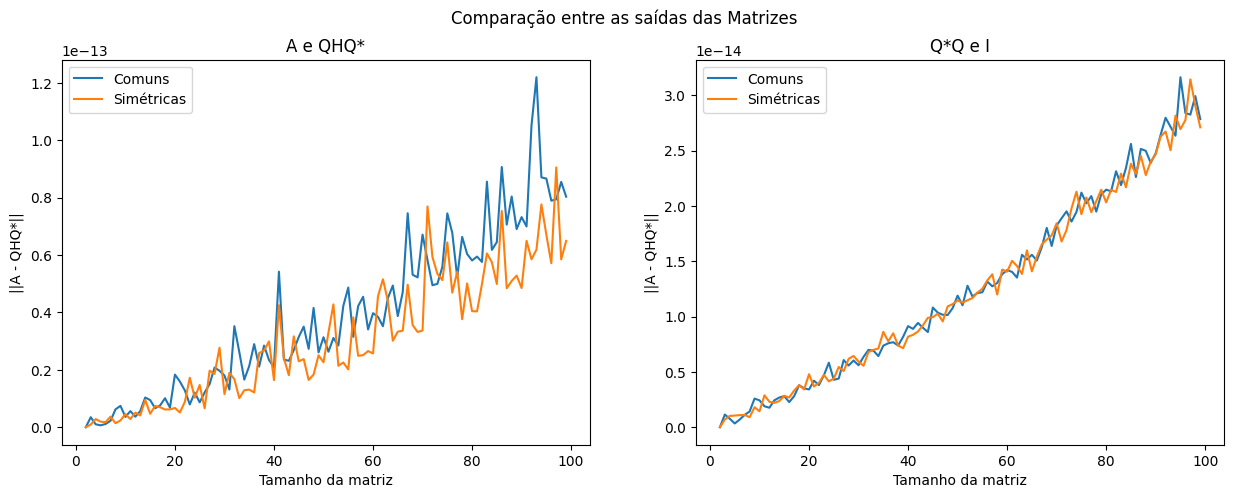

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação entre as saídas das Matrizes")

axes[0].set_title("A e QHQ*")
axes[1].set_title("Q*Q e I")

axes[0].plot(range(2, 100), norms_difference_normals, label="Comuns")
axes[0].plot(range(2, 100), norms_difference_symetrics, label="Simétricas")

axes[1].plot(range(2, 100), identities_difference_normals, label="Comuns")
axes[1].plot(range(2, 100), identities_difference_symetrics, label="Simétricas")

axes[0].set_xlabel("Tamanho da matriz")
axes[0].set_ylabel("||A - QHQ*||")
axes[1].set_xlabel("Tamanho da matriz")
axes[1].set_ylabel("||A - QHQ*||")

axes[0].legend()
axes[1].legend()
plt.show()

Aqui podemos ver que a função está retornando matrizes satisfatórias

**c) _Complexidade_. Realize testes para matrizes n ×n, com n variando de 10 até 1000 (ou mais, se o seu computador aguentar!). Quanto tempo seu algoritmo leva para calcular a forma de Hessemberg? Para matrizes pequenas, repita o teste até levar pelo menos 1 segundo, para evitar erros de medida de tempos muito pequenos. Qual parece ser a complexidade observada do algoritmo?**

Como eu posteriormente usarei um argumento de convergência para entender melhor qual que é o grau do polinômio da complexidade, para evitar que os códigos demorassem muito, eu armazenei os valores que rodei e peguei anterioremente em uma arquivo `registered_times.csv`. Assim, se eu quiser rodar para mais matrizes, não preciso fazer para os tamanhos que já rodei anteriormente (Muito útil com matrizes muito grandes)

In [8]:
n = 1701
# sizes = [*range(10, 101, 5), *range(150, 200, 50), *range(500, 601, 20), *range(800, 901, 20), 1000]
sizes = [*range(150, 500, 20)]
registered_times_exist = os.path.exists("times.csv")

In [9]:
normal_times = []


def calculate_normal_matrix(size):
    total_time = 0
    count = 0
    
    matrix = np.random.random_sample((size, size))  # Gero a matriz

    while total_time < 1:
        count += 1
        initial = time.perf_counter()  # Inicio o contador de performance
        _, _, _ = to_hessenberg(matrix)  # Executo a função da matriz de hessenberg
        finish = time.perf_counter()  # Finalizo o contador

        performance = finish-initial

        total_time += performance

    return total_time / count


if not registered_times_exist:    
    for size in sizes:
        print(f"Calculando {size}x{size}")
        normal_times.append(calculate_normal_matrix(size))

In [10]:
symmetric_times = []

def calculate_symetric_matrix(size):
    matrix = np.random.random_sample((size, size))
    matrix = (matrix + matrix.T) / 2
    total_time = 0
    count = 0

    while total_time < 1:
        count += 1
        initial = time.perf_counter()  # Inicio o contador de performance
        _, _, _ = to_hessenberg(matrix)  # Executo a função da matriz de hessenberg
        finish = time.perf_counter()  # Finalizo o contador

        performance = finish-initial

        total_time += performance

    return total_time / count


if not registered_times_exist:
    for i in sizes:
        print(f"Calculando {i}x{i}")
        symmetric_times.append(calculate_symetric_matrix(i))

In [11]:
if registered_times_exist:
    df = pd.read_csv("registered_times.csv")
    normal_times = df["TIME_NORMAL"]
    symmetric_times = df["TIME_SYMMETRIC"]
    sizes = df["SIZES"]

Fazendo uma análise na função que eu fiz, é possível ver que a complexidade do algoritmo é $O(m^3)$. Vejamos:
```py
for k in range(m-2):                                                    # Tenho m-2 iterações => O(m)
    v_k = sign(x[0]) * np.linalg.norm(x) * np.eye(x.shape[0], 1) + x    # O(m)
    v_k = v_k / np.linalg.norm(v_k)                                     # O(m)
    M[k+1:m, k:m] -= 2 * v_k @ (v_k.T @ M[k+1:m, k:m])                  # O(m^2)
    M[0:m, k+1:m] -= 2 * (M[0:m, k+1:m] @ v_k) @ v_k.T                  # O(m^2)

    Q[k+1:m, k+1:m] @= v_k @ v_k.T                                      # O(m^2)

Q = np.eye(m)
for k, v_k in enumerate(reflectors):                                    # O(m)
    H_k = np.eye(m)
    H_k[k + 1:m, k + 1:m] -= 2 * (v_k @ v_k.T)                          # O(m^2)
    Q = Q @ H_k                                                         # O(m^2)
```

Chegamos então que:
$$
O(m)(O(2m) + O(3m^2)) + O(m)(O(2m^2)) = O(m^3)
$$

Certo, teoricamente o algoritmo é $O(m^3)$, mas isso vale mesmo na prática? Na verdade, tem um jeito interessante de visualizarmos isso. Vamos supor que nosso algoritmo tem complexidade $O(m^p)$, ou seja, a função de custo $f$ pode ser dada por:
$$
    f(m) = km^p
$$
Porém, se tirarmos o log em ambos os lados da igualdade, conseguimos um resultado interessante:
$$
    log(f(m)) = p log(m) + log(k)
$$
Ou seja, se plotarmos $m$ e $f(m)$ em gráficos onde os eixos são na escala logarítmica, temos que o resultado são retas (Famoso gráfico **loglog**). Mas como que isso me ajuda? Acontece que agora eu posso calcular diretamente o $p$ como um coeficiente de reta:
$$
    p = \frac{
        log(f(m_{j+1}) - f(m_j))
    }{
        log(m_{j+1}) - log(m_j)
    }
$$

No nosso caso, não temos pontos certinhos que nos dão uma inclinação perfeita, porém, podemos fazer uma média com todos os pontos que temos e obter um valor aproximado de qual seria o $p$ que esse polinômio está convergindo

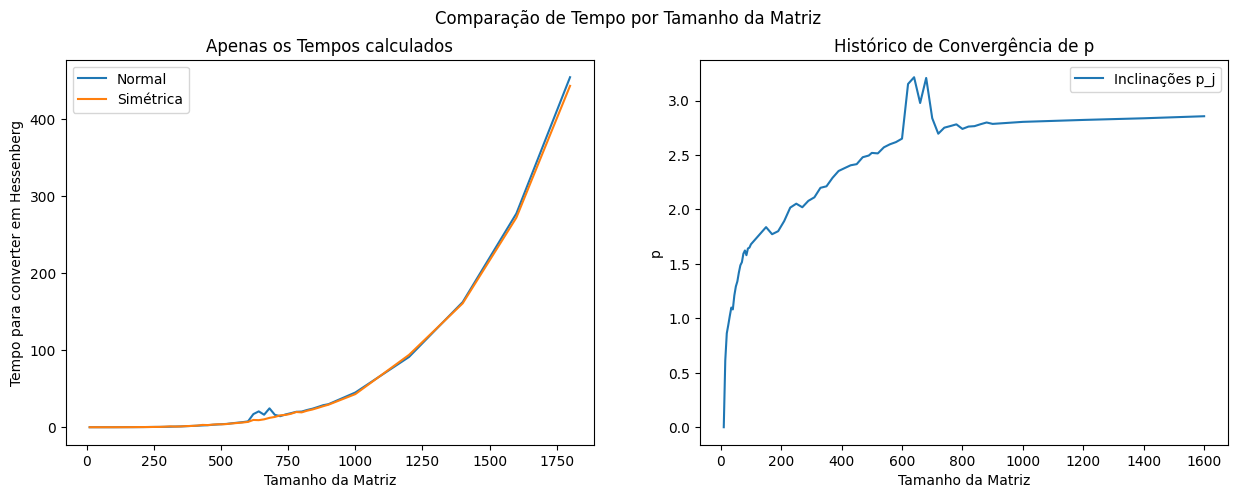

np.float64(2.923410309494014)

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação de Tempo por Tamanho da Matriz")
axes[0].plot(sizes, normal_times, label="Normal")
axes[0].plot(sizes, symmetric_times, label="Simétrica")

axes[0].set_title("Apenas os Tempos calculados")
axes[1].set_title("Histórico de Convergência de p")

inclination_sum = 0
inclinations_history = []

for j in range(len(sizes)-1):
    inclination_j = (np.log(normal_times[j+1]) - np.log(normal_times[j]))/(np.log(sizes[j+1]) - np.log(sizes[j]))
    inclinations_history.append(inclination_sum/(j+1))
    inclination_sum += inclination_j

axes[1].plot(sizes[:-1], inclinations_history, label="Inclinações p_j")

inclination_average = inclination_sum/(len(sizes)-1)

axes[0].set_ylabel("Tempo para converter em Hessenberg")
axes[0].set_xlabel("Tamanho da Matriz")
axes[1].set_ylabel("p")
axes[1].set_xlabel("Tamanho da Matriz")
axes[0].legend()
axes[1].legend()

plt.show()
inclination_average

Como podemos ver, o valor converge bem para $p = 3$, o que é um forte indicativo de que a complexidade do algoritmo é $O(n^3)$

In [13]:
# Esse trecho serviu para que, quando eu executasse o código novamente, não precisasse executar várias vezes
# apenas uma e as informações eram armazenadas em um arquivo separado
if not registered_times_exist:
    df = pd.DataFrame(columns=['TIME_NORMAL', 'TIME_SYMMETRIC', 'SIZES'])
    df['TIME_NORMAL'] = pd.Series(normal_times)
    df['TIME_SYMMETRIC'] = pd.Series(symmetric_times)
    df['SIZES'] = pd.Series(sizes)

    df.to_csv('times.csv', index=False)

**d\) A complexidade do seu código muda se A for simétrica? O que precisaria ser feito para acelerar este cálculo?**

Como a matriz é simétrica, temos que, ao fazer $Q_j^* A Q_j$, as linhas da coluna e da linha $j$ são zeradas. Isso da um efeito interessante.
$$
    M=
    \begin{bmatrix}
        x & x & x & x & x  \\
        x & x & x & x & x  \\
        x & x & x & x & x  \\
        x & x & x & x & x  \\
        x & x & x & x & x  \\
    \end{bmatrix}

    \rightarrow

    Q_1 M=
    \begin{bmatrix}
        x & x & 0 & 0 & 0  \\
        x & x & x & x & x  \\
        0 & x & x & x & x  \\
        0 & x & x & x & x  \\
        0 & x & x & x & x  \\
    \end{bmatrix}
$$
Quando vamos aplicar a próxima transformação, os valores da matriz zeram em cima também, o que indica que não precisamos utilizar essas linhas, ou seja, acada iteração, eu vou ignorar as linhas anteriores na multiplicação pela direita da matriz. Então, se usarmos a definição do algoritmo do livro:

$$
    A_{k+1:m, k:m} = A_{k+1:m, k:m} - 2v_k v_k^* A_{k+1:m, k:m}  \\
    A_{1:m, k:m} = A_{1:m, k:m} - 2 A_{1:m, k:m} v_k v_k^*
$$

Basta trocar a segunda linha por

$$
    A_{k+1:m, k:m} = A_{k+1:m, k:m} - 2 A_{k+1:m, k:m} v_k v_k^*  \\
$$

A desvantagem? A parte de cima da matriz não é atualizada, então ao final do algoritmo, ou temos a opção de ignorar completamente a parte superior da diagonal, ou atualizar ela com base no resultado da inferior da diagonal

In [14]:
def to_hessenberg(A: np.ndarray, symmetric: bool = False) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """Função que recebe uma matriz A e calcula sua forma de Hessenberg.

    Args:
        A (np.ndarray): Matriz que será calculada

    Returns:
        tuple[list[np.ndarray], np.ndarray, np.ndarray]: Lista contendo os vetores de reflexão v_i, a matriz de
        Hessenberg e a matriz ortogonal Q
    """
    if A.shape[0] != A.shape[1]:
        raise ValueError("Você precisa passar uma matriz quadrada")

    M = A.copy()

    reflectors = []
    m = M.shape[0]
    Q = np.identity(m)

    for k in range(m-2):
        x = M[k+1:m, k].reshape(-1, 1)
        v_k = sign(x[0]) * np.linalg.norm(x) * np.eye(x.shape[0], 1) + x
        v_k = v_k / np.linalg.norm(v_k)
        M[k+1:m, k:m] -= 2 * v_k @ (v_k.T @ M[k+1:m, k:m])

        if not symmetric:
            M[0:m, k+1:m] -= 2 * (M[0:m, k+1:m] @ v_k) @ v_k.T
        else:
            M[k+1:m, k+1:m] -= 2 * (M[k+1:m, k+1:m] @ v_k) @ v_k.T

        Q[k+1:m, k+1:m] @= v_k @ v_k.T

        reflectors.append(v_k)
    
    return reflectors, M, Q

Mas isso funciona? Vamos fazer uns testes de comparação

In [15]:
matrices_to_symetrize = [np.random.random_sample((m, m)) for m in range(2, 100)]
symetric_matrices = []
for matrix in matrices_to_symetrize:
    m = (matrix + matrix.T)/2
    symetric_matrices.append(m)

In [16]:
norms_difference_symetrics = []

identities_difference_symetrics = []

for A in symetric_matrices:
    _, H, Q = to_hessenberg(A, True)

    H = np.tril(H) + np.tril(H, -1).T  # Ajuste da diagonal

    norm_symetric = np.linalg.norm(
        A - Q @ H @ Q.T
    )
    norms_difference_symetrics.append(norm_symetric)

    identity_difference_symetric = np.linalg.norm(
        np.identity(Q.shape[0]) - Q.T @ Q
    )
    identities_difference_symetrics.append(identity_difference_symetric)

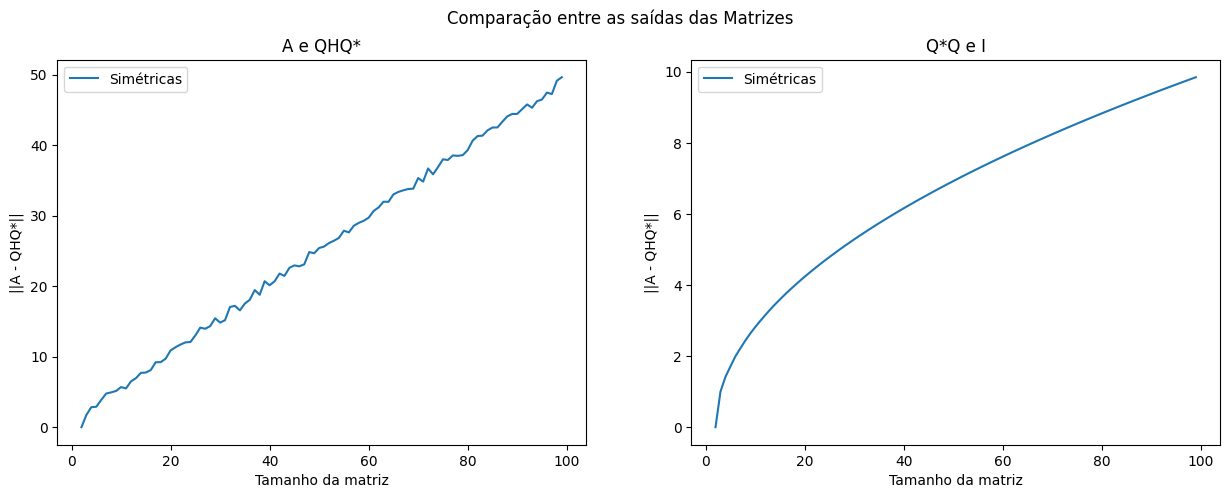

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação entre as saídas das Matrizes")

axes[0].set_title("A e QHQ*")
axes[1].set_title("Q*Q e I")

axes[0].plot(range(2, 100), norms_difference_symetrics, label="Simétricas")

axes[1].plot(range(2, 100), identities_difference_symetrics, label="Simétricas")

axes[0].set_xlabel("Tamanho da matriz")
axes[0].set_ylabel("||A - QHQ*||")
axes[1].set_xlabel("Tamanho da matriz")
axes[1].set_ylabel("||A - QHQ*||")

axes[0].legend()
axes[1].legend()
plt.show()

Como podemos ver, após o ajuste da matriz retornada pelo algoritmo, conseguimos obter uma ótima aproximação da matriz original. Infelizmente não é possível diminuir o grau da complexidade do algoritmo, porém, é possível diminuir seu tempo de execução **na prática**. Ou seja, a mudança que eu realizei, não deixa de fazer com que a complexidade seja $O(n^3)$, porém, faz com que a constante multiplicativa (Definição formal de $O(\phi(n))$) diminua, diminuindo o tempo de execução significativamente em matrizes muito grandes (Mudança que é perceptivel em matrizes realmente muito grandes)

### 2. Matrizes ortogonais

**a\) Um pouco de teoria. O que você pode dizer dos autovalores de uma matriz ortogonal? O que isto implica para o método da potência? E para a iteração inversa?**

Seja $Q$ uma matriz ortogonal e $v$ um autovetor de $Q$ associado ao autovalor $\lambda$
$$
Qv = \lambda v \\
$$
Como $Q$ é ortogonal, temos que $\|Q v\|_2 = \|v\|_2$
$$
\|Qv\|_2^2 = (Qv)^T(Qv) = \|v\|_2^2\\

\|Qv\|_2^2 = (\lambda v)^T(\lambda v) = \|v\|_2^2\\

\|v\|_2^2 = \lambda^2 v^T v \\

\|v\|_2^2 = \lambda^2 \|v\|_2^2  \Rightarrow  \lambda^2 = 1  \Rightarrow  |\lambda| = 1
$$

Ou seja, todos os autovalores de $Q$ tem módulo $1$. Mas como isso afeta o método da potência e da iteração inversa?

**Método da Potência**: O algoritmo **nunca vai convergir**, tendo em vista que ele utiliza do coeficiente de Rayleigh. Acontece que todos os autovalores vão ter mesmo módulo (Contraria a condição necessária para o algoritmo convergir)

**Iteração Reversa**: Por conta do uso de Shifts, o algoritmo provavelmente conseguirá convergir, já que, querendo ou não, estamos usando um shift para acelerar a convergência

Vamos conferir na prática

In [18]:
def power_iteration(A, max_iter=500):
    v = np.random.random_sample((A.shape[1], 1)).astype(np.complex128)
    v = v / np.linalg.norm(v)
    eigenvalue = 0

    for i in range(max_iter):
        w = A @ v
        v = w / np.linalg.norm(w)

        eigenvalue = v.conj().T @ A @ v
    
    return eigenvalue[0, 0]


def inverse_iteration(A, shift, max_iter=500):
    v = np.random.random_sample((A.shape[1], 1)).astype(np.complex128)
    v = v / np.linalg.norm(v)
    eigenvalue = 0
    I = np.identity(A.shape[0])

    for i in range(max_iter):
        w = np.linalg.solve(A - shift*I, v)
        v = w / np.linalg.norm(w)

        eigenvalue = v.conj().T @ A @ v
    
    return eigenvalue[0, 0]

In [19]:
np_eigenvalues = []
power_iteration_eigenvalues = []
inverse_iteration_eigenvalues = []

for i in range(1000):
    A = np.random.random_sample((40, 40)).astype(np.complex128)
    Q, _ = np.linalg.qr(A)

    real_eigvals = np.linalg.eigvals(Q)
    biggest_eigenvalue = real_eigvals[abs(real_eigvals).argmax()]
    
    biggest_eigenvalue_power_iteration = power_iteration(Q)
    biggest_eigenvalue_inverse_iteration = inverse_iteration(Q, biggest_eigenvalue+1e-10)

    np_eigenvalues.append(biggest_eigenvalue)
    power_iteration_eigenvalues.append(biggest_eigenvalue_power_iteration)
    inverse_iteration_eigenvalues.append(biggest_eigenvalue_inverse_iteration)

np_eigenvalues = np.array(np_eigenvalues)
power_iteration_eigenvalues = np.array(power_iteration_eigenvalues)
inverse_iteration_eigenvalues = np.array(inverse_iteration_eigenvalues)

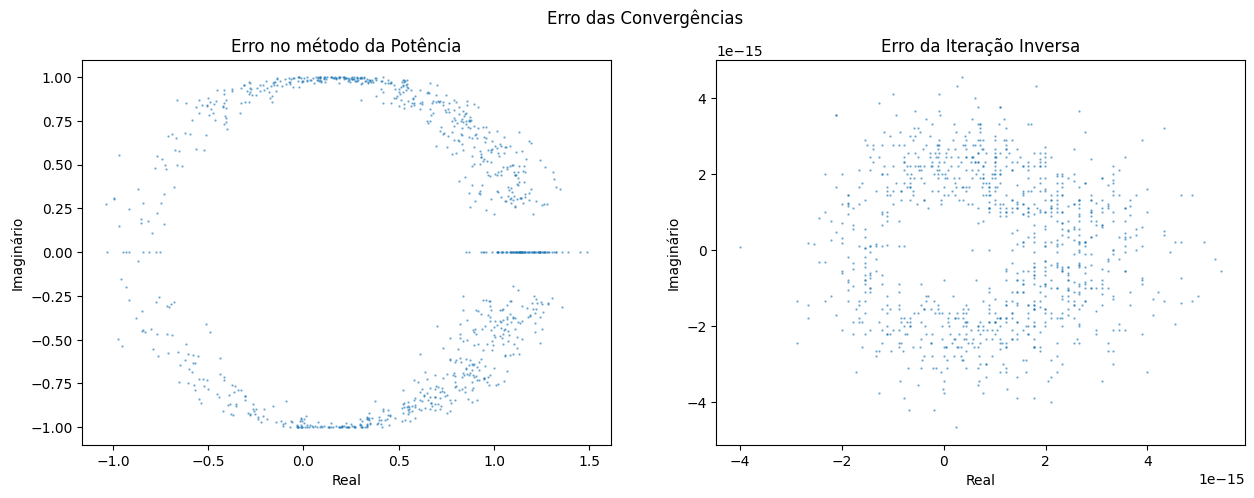

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Erro das Convergências")

axes[0].set_title("Erro no método da Potência")
axes[1].set_title("Erro da Iteração Inversa")

axes[0].set_xlabel("Real")
axes[0].set_ylabel("Imaginário")
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Imaginário")

diff_1 = np_eigenvalues - power_iteration_eigenvalues
diff_2 = np_eigenvalues - inverse_iteration_eigenvalues

axes[0].scatter(diff_1.real, diff_1.imag, alpha=.5, s=.5)
axes[1].scatter(diff_2.real, diff_2.imag, alpha=.5, s=.5)

plt.show()

In [21]:
mean_power_iteration = diff_1.mean()
mean_inverse_iteration = diff_2.mean()

print(f"Média do método da potência: {mean_power_iteration}")
print(f"Média do método da iteração inversa: {mean_inverse_iteration}")

Média do método da potência: (0.46910843498114974+0.043934534983747615j)
Média do método da iteração inversa: (9.62085879713248e-16+1.1852414666788385e-16j)


Ou seja, como previmos, o método da potência não converge enquanto o da iteração reversa **sim**

**b\) O caso 2 ×2. Calcule os autovalores de $M=\begin{bmatrix} a & b \\ c & d \end{bmatrix}$**

$$
    M - \lambda I = \begin{bmatrix} a - \lambda & b \\ c & d - \lambda \end{bmatrix}  \\

    det(M - \lambda I) = (a - \lambda)(d - \lambda) - bc  \\

    0 = ad - (a + d)\lambda + \lambda^2 - bc  \\
$$

$$
    \Delta = (a+d)^2 - 4(ad - bc) \Leftrightarrow \Delta = a^2 + 2ad + d^2 - 4(ad - bc)  \\
    \Leftrightarrow \Delta = a^2 - 2ad + d^2 + 4bc \Leftrightarrow \Delta = (a-d)^2 + 4bc  \\
    
    \Rightarrow \lambda = \frac{
        a + d \pm \sqrt{(a-d)^2 + 4bc}
    }{
        2
    }
$$

**c\) Construa matrizes ortogonais de ordem 4 a partir da fatoração `QR` de matrizes aleatórias A. Para cada matriz Q assim obtida, transforme-a em sua forma de Hessemberg, e calcule (analiticamente) os autovalores do bloco `H[3:4,3:4]`. O que você observa?**

In [22]:
reals = []
imaginaries = []

for i in range(60000):
    A = 10*np.random.random_sample((4, 4))

    Q, _ = np.linalg.qr(A)

    _, H, _ = to_hessenberg(Q)

    H_new = H[2:, 2:]

    a = float(H_new[0, 0])
    b = float(H_new[0, 1])
    c = float(H_new[1, 0])
    d = float(H_new[1, 1])

    delta_sqrt = ((a - d)**2 + 4*b*c)**(1/2)
    lambda_1 = complex((a + d + delta_sqrt)/2)
    lambda_2 = complex((a + d - delta_sqrt)/2)

    reals.append(lambda_1.real)
    reals.append(lambda_2.real)

    imaginaries.append(lambda_1.imag)
    imaginaries.append(lambda_2.imag)

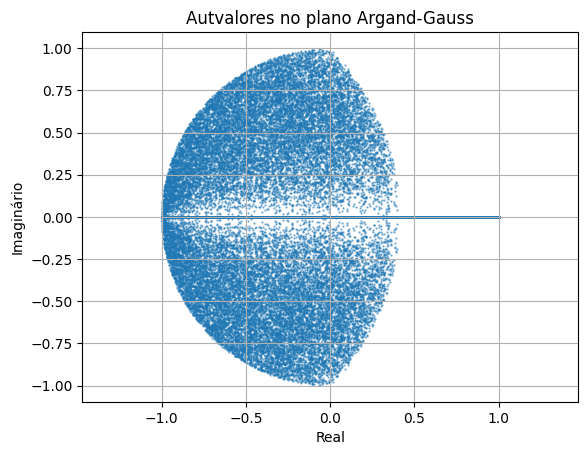

In [23]:
plt.title("Autvalores no plano Argand-Gauss")

plt.xlabel("Real")
plt.ylabel("Imaginário")

plt.axis("equal")

plt.grid()

plt.scatter(reals, imaginaries, alpha=.5, s=.5)

plt.show()

A gente consegue ver que os autovalores ficam perto de 1, ou seja, os autovalores dessa submatriz tem valor absoluto menor que 1. O que faz sentido, tendo em vista que $\|Q\| = 1$ (Sabemos que a forma de Hessenberg de uma Ortogonal vai ser Ortogonal também), ou seja, se pegamos um bloco de $Q$, nenhuma multiplicação de algum vetor vai ser capaz de sequer atingir o mesmo tamanho, ou seja: $sup\{ \frac{\|\tilde{Q}x\|}{\|x\|} \} < 1$, ou seja, o valor dos autovalores de $Q$ vai ficar em torno dos valores de módulo $1$.

Da pra imaginar isso também tendo em vista que uma matriz ortogonal $Q$ tem colunas de módulo $1$, se eu tenho qualquer valor maior do que $1$, é impossível que o módulo do a coluna seja igual a $1$. Mas aonde eu quero chegar com isso? Acontece que, pegando esse bloco $2 \times 2$ eu tenho, não somente valores menores do que 1, mas eu tenho valores que, ao terem seus quadrados somados, **falta** para chegar em $1$ (Retirei os valores do bloco `Q[1:2, 3:4]`), ou seja, nenhum vetor que eu multiplicar essa matriz sequer vai chegar perto do tamanho que tinha originalmente, sempre irá diminuir.

**d) _Shifts_. Continuando o exercício anterior, use um dos autovalores do bloco final como _shift_ (fixo) para a iteração QR. O algoritmo parece convergir?**

In [24]:
def shifted_qr(A: np.ndarray, shift: float = None, max_iter: int = 500):
    """Função que calcula os autovalores de uma matriz utilizando do algoritmo QR com shifts

    Args:
        A (np.ndarray): Matriz que desejo calcular
        shift (float, optional): Caso eu queira usar um shift em específico. Defaults to None.
        max_iter (int, optional): Quantidade máxima de iterações do algoritmo. Defaults to 500.

    Returns:
        (tuple): A matriz com os autovalores na diagonal e o histórico de convergência dessa matriz
    """
    M = np.random.random_sample(A.shape)
    Q, _ = np.linalg.qr(M)
    A_k = Q @ A @ Q.T
    I = np.identity(A.shape[0])
    A_k = A_k.astype(np.complex128)

    history = []

    counter = 0
    while counter <= max_iter:
        counter += 1

        if shift is not None:
            mi = shift
        else:
            # Wilkinson Shift
            a_m_1 = A_k[-2, -2]
            a_m = A_k[-1, -1]
            b_m = A_k[-2, -1]
            delta = (a_m_1 - a_m)/2

            mi = a_m - (sign(delta)*b_m**2)/(abs(delta) + (delta**2 + b_m**2)**(1/2))

        Q, R = np.linalg.qr(A_k - mi * I)

        A_k = R @ Q + mi*I

        history.append(A_k)

    return np.diag(A_k), history

Vamos fazer o teste para várias matrizes

In [25]:
reals_analytic = []
imaginaries_analytic = []

reals_convergence = []
imaginaries_convergence = []

for i in range(2000):
    A = 10*np.random.random_sample((4, 4))

    Q, _ = np.linalg.qr(A)

    _, H, _ = to_hessenberg(Q)

    H_new = H[2:, 2:]

    a = float(H_new[0, 0])
    b = float(H_new[0, 1])
    c = float(H_new[1, 0])
    d = float(H_new[1, 1])

    delta_sqrt = ((a - d)**2 + 4*b*c)**(1/2)
    lambda_1 = complex((a + d + delta_sqrt)/2)
    lambda_2 = complex((a + d - delta_sqrt)/2)

    reals_analytic.append(lambda_1.real)
    reals_analytic.append(lambda_2.real)

    imaginaries_analytic.append(lambda_1.imag)
    imaginaries_analytic.append(lambda_2.imag)

    # Faço o cálculo dos autovalores pelo algoritmo QR
    lambdas, _ = shifted_qr(H_new, lambda_1)

    reals_convergence.append(lambdas[0].real)
    reals_convergence.append(lambdas[1].real)

    imaginaries_convergence.append(lambdas[0].imag)
    imaginaries_convergence.append(lambdas[1].imag)

Agora eu vou plotar a diferença entre os autovalores e comparar se estão convergindo

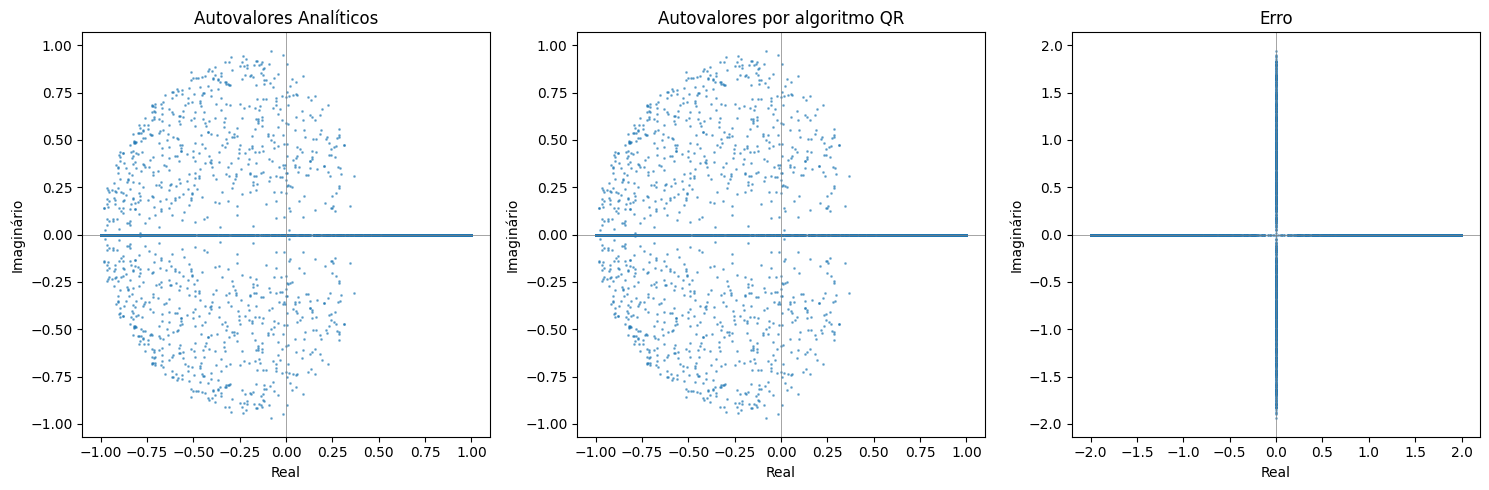

Erro médio real: -5.995204332975845e-18
Erro imaginário real: 1.1102230246251566e-19
Erro real máximo: 1.998977851782916
Erro imaginário máximo: 1.94146494894452


In [26]:
reals_analytic = np.array(reals_analytic)
imaginaries_analytic = np.array(imaginaries_analytic)

reals_convergence = np.array(reals_convergence)
imaginaries_convergence = np.array(imaginaries_convergence)

reals_error = reals_analytic - reals_convergence
imaginaries_error = imaginaries_analytic - imaginaries_convergence

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# ax.title("Diferença dos Autovalores e Autovetores no plano Argand-Gauss")

ax[0].set_title("Autovalores Analíticos")
ax[1].set_title("Autovalores por algoritmo QR")
ax[2].set_title("Erro")

for i in range(3):
    ax[i].axhline(0, color='gray', linewidth=0.5)
    ax[i].axvline(0, color='gray', linewidth=0.5)
    ax[i].set_ylabel("Imaginário")
    ax[i].set_xlabel("Real")


ax[0].scatter(reals_analytic, imaginaries_analytic, s=1, alpha=.5)
ax[1].scatter(reals_convergence, imaginaries_convergence, s=1, alpha=.5)
ax[2].scatter(reals_error, imaginaries_error, s=1, alpha=.5)

plt.tight_layout()
plt.show()

print(f"Erro médio real: {reals_error.mean()}")
print(f"Erro imaginário real: {imaginaries_error.mean()}")

print("="*40)

print(f"Erro real máximo: {reals_error.max()}")
print(f"Erro imaginário máximo: {imaginaries_error.max()}")

Como a gente pode ver, escolhendo um autovalor como shift único não é tão interessante, já que as vezes ele converge, as vezes não converge, já que um autovalor pode ta bem distante do outro e acaba que não tem uma convergência muito legal. Mas e se, caso um autovalor não converja, a gente tenta pegar o outro e usar como shift?

In [27]:
reals_analytic = []
imaginaries_analytic = []

reals_convergence = []
imaginaries_convergence = []

for i in range(2000):
    A = 10*np.random.random_sample((4, 4))

    Q, _ = np.linalg.qr(A)

    _, H, _ = to_hessenberg(Q)

    H_new = H[2:, 2:]

    a = float(H_new[0, 0])
    b = float(H_new[0, 1])
    c = float(H_new[1, 0])
    d = float(H_new[1, 1])

    delta_sqrt = ((a - d)**2 + 4*b*c)**(1/2)
    lambda_1 = complex((a + d + delta_sqrt)/2)
    lambda_2 = complex((a + d - delta_sqrt)/2)

    reals_analytic.append(lambda_1.real)
    reals_analytic.append(lambda_2.real)

    imaginaries_analytic.append(lambda_1.imag)
    imaginaries_analytic.append(lambda_2.imag)

    # Faço o cálculo dos autovalores pelo algoritmo QR
    lambdas, _ = shifted_qr(H_new, lambda_1)

    if not np.allclose(lambdas, [lambda_1, lambda_2]):
        lambdas, _ = shifted_qr(H_new, lambda_2)

    reals_convergence.append(lambdas[0].real)
    reals_convergence.append(lambdas[1].real)

    imaginaries_convergence.append(lambdas[0].imag)
    imaginaries_convergence.append(lambdas[1].imag)

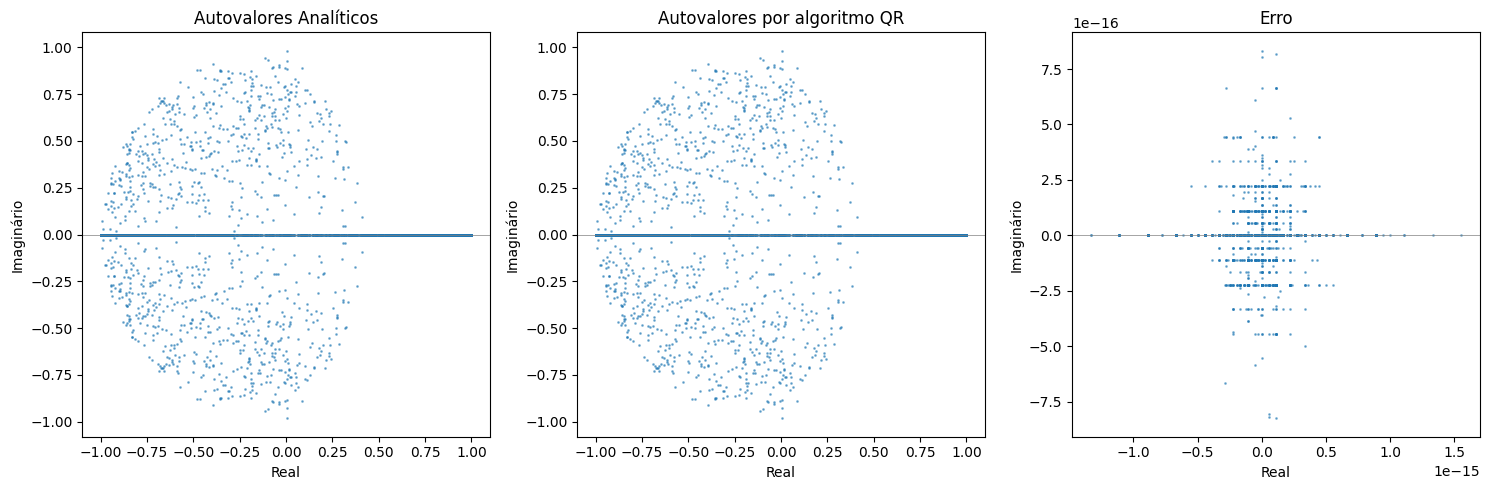

Erro médio real: 5.800481622797448e-19
Erro imaginário real: -4.475586568020162e-19
Erro real máximo: 1.5543122344752192e-15
Erro imaginário máximo: 8.326672684688674e-16


In [28]:
reals_analytic = np.array(reals_analytic)
imaginaries_analytic = np.array(imaginaries_analytic)

reals_convergence = np.array(reals_convergence)
imaginaries_convergence = np.array(imaginaries_convergence)

reals_error = reals_analytic - reals_convergence
imaginaries_error = imaginaries_analytic - imaginaries_convergence

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# ax.title("Diferença dos Autovalores e Autovetores no plano Argand-Gauss")

ax[0].set_title("Autovalores Analíticos")
ax[1].set_title("Autovalores por algoritmo QR")
ax[2].set_title("Erro")

for i in range(3):
    ax[i].axhline(0, color='gray', linewidth=0.5)
    ax[i].set_ylabel("Imaginário")
    ax[i].set_xlabel("Real")


ax[0].scatter(reals_analytic, imaginaries_analytic, s=1, alpha=.5)
ax[1].scatter(reals_convergence, imaginaries_convergence, s=1, alpha=.5)
ax[2].scatter(reals_error, imaginaries_error, s=1, alpha=.5)

plt.tight_layout()
plt.show()

print(f"Erro médio real: {reals_error.mean()}")
print(f"Erro imaginário real: {imaginaries_error.mean()}")

print("="*40)

print(f"Erro real máximo: {reals_error.max()}")
print(f"Erro imaginário máximo: {imaginaries_error.max()}")

Agora sim, a gente tem uma estimativa muito muito boa. Mas por que isso aconteceria? Bem, o shift é usado justamente como uma aproximação do autovalor, então se eu pego um shift ruim, eu vou ter uma aproximação ruim. Se eu pegar um dos autovalores calculados analiticamente é ruim então? Sim, já que pode acontecer de $A^{(k)} - \mu^{(k)}I$ ficar muito próxima de ser singular, aí causa instabilidades numéricas. Como a gente viu, o shift só serve para acelerar a convergência, se eu coloco uma aproximação boa de um autovalor, não necessariamente vai convergir para aquele autovalor em específico, se o algoritmo tenta naturalmente convergir para o outro, isso acaba dando os erros numéricos gigantes que a gente viu, por isso, se escolher uma boa aproximação do outro, isso acaba por corrigir o problema